# Relative efficiency in other programming languages 

Running the code cells below will compute and automatically generate the following figures:

-  **From Section 5.3.3**:
   
    - **Figure 9**, saved as **`Fig20.pdf`**


<ul id="top">
    <li><a href="#Loading-packages-and-functions">Loading packages and functions</a></li>
    <li><a href="#Definition-of-the-N-body-problem">Definition of the N-body problem</a></li>
    <li><a href="#Load-Hairer's-implementation-results">Load Hairer's implementation results</a></li>
    <li><a href="#IRKGL12-integrations-(s=6)">IRKGL12 integrations (s=6)</a></li>
    <li><a href="#SS05(r=8)">SS05(r=8)</a></li>
    <li><a href="#Benchmarks-diagrams">Benchmarks diagrams</a></li>
    <ul>
        <li><a href="#Work-precision-diagrams">Work-precision-diagrams</a></li>
    </ul>
</ul>

## Loading packages and functions

In [1]:
using LinearAlgebra
using Plots
#using OrdinaryDiffEq
using LaTeXStrings

PATH_IRKGL="../../../../Clone_IRKGL_16_nov_2025/IRKGaussLegendre.jl/"
include(string(PATH_IRKGL, "src/IRKGaussLegendre.jl"))
using .IRKGaussLegendre 

PATH_Splitting="../../"
include(string(PATH_Splitting,"/src/SplittingMethods.jl"))
using .SplittingMethods  ## bertsio lokala exekutatzeko  

include("../Aux_functions.jl")

PATH_ODES="../../ODEProblems/"
include(string(PATH_ODES,"Initial6Body.jl"))
include(string(PATH_ODES,"Nbody.jl"));

##### <a href="#top">Back to the top</a>

## Definition of the N-body problem

In Nbody.jl below, the following functions are defined: NbodyEnergy(u,Gm), NbodyODE!(du,u,Gm,t), and NbodyODE1!(du,u,Gm,t), where

\begin{equation*}
u = 
\left(\begin{matrix}
q_1  & v_1\\
\vdots & \vdots \\
q_N  & v_N
\end{matrix}
\right) \in \mathbb{R}^{2 \times 3\times N}, \quad
Gm = (G\,  m_1, \ldots,G\,  m_N) \in \mathbb{R}^N.
\end{equation*}

The energy, as a function of the positions $q_1,\ldots,q_N \in \mathbb{R}^3$ and the velocities $v_1,\ldots,v_N \in \mathbb{R}^3$ of the $N$ bodies is:
\begin{equation*}
\begin{split}
\mathrm{Energy}(q_1,\ldots,q_N,v_1,\ldots,v_N) = 
\frac12 \sum_{i=1}^{N} m_i \, \|v_i\|^2
- G \sum_{1\leq i < j \leq N} \frac{m_i m_j}{\|q_i-q_j\|}.
\end{split}
\end{equation*}


The ODE system of the N-body problem,
as a function of the positions $q_1,\ldots,q_N \in \mathbb{R}^3$ and the velocities $v_1,\ldots,v_N \in \mathbb{R}^3$ of the $N$ bodies is:
\begin{equation*}
\begin{split}
\frac{d}{dt} q_i &= v_i, \\
\frac{d}{dt} v_i &= G\, 
\sum_{j \neq i} \frac{m_j}{\|q_j-q_i\|^3}\,
(q_j-q_i).
\end{split}
\end{equation*}
This system of ODEs can be writen in compact form as
\begin{equation*}
\frac{d u}{dt} = f(t,u,Gm)
\end{equation*}




### Initial value problem: 6-body problem (outer solar system)

We consider $N=6$ bodies of the outer solar system: the Sun, Jupiter, Saturn, Uranus, Neptune and Pluto.
The initial values $u_{00}$ are taken from DE430, Julian day (TDB) 2440400.5 (June 28, 1969). 

In [2]:
u0, Gm, bodylist = Initial6Body(Float64)

u0_B=BigFloat.(u0)
Gm_B=BigFloat.(Gm)

q0=u0[:,:,1]
v0=u0[:,:,2]

N = length(Gm)

show(bodylist)
E0=NbodyEnergy(u0,Gm)

["Sun" "Jupiter" "Saturn" "Uranus" "Neptune" "Pluto"]

-9.522620605966966e-12

In [3]:
# Testing: center of mass of the outer solar system at the origin of coordinates with zero velocity

q0_ = zeros(3)
v0_ = zeros(3)
Gm0_ = 0.
for i in 1:6
    Gmi = Gm[i]
    qi = u0[:,i,1]
    vi = u0[:,i,2]
    q0_ += Gmi*qi
    v0_ += Gmi*vi
    Gm0_ += Gmi
end
(q0_/Gm0_, v0_/Gm0_)

([1.417048569677335e-18, 9.119357686204585e-20, 1.5082339679877506e-19], [1.0942040830907497e-22, -2.709864045560887e-22, 1.6237832716049163e-22])

In [4]:
t0=0.
tF=1e7   #1e9  # days

tspan= (t0,tF)
tspan_B=(BigFloat(t0),BigFloat(tF))

Jupiter_period = 11.9*365
tF/Jupiter_period

2302.290779325429

In [5]:
year=365.25
tF/year

27378.507871321013

In [6]:
prob = ODEProblem{true,SciMLBase.FullSpecialize}(NbodyODE!, u0, tspan , Gm)

HAM=NbodyEnergy
@show(HAM(u0,Gm));

HAM(u0, Gm) = -9.522620605966966e-12


##### <a href="#top">Back to the top</a>

## Load Hairer's implementation results

In [7]:
#using Pkg
#Pkg.add(["CSV", "DataFrames"])

using CSV, DataFrames
df_irk = CSV.read("Hairer_irk2_o2.txt", DataFrame; delim=' ', ignorerepeated=true);
names(df_irk);

df_comp = CSV.read("Hairer_comp_o2.txt", DataFrame; delim=' ', ignorerepeated=true);

In [8]:
fnc_H_irk=df_irk[!, "calls,"]
rel_err_H_irk=df_irk[!, "rel-err"]
cpu_H_irk=df_irk[!, "time,"];

fnc_H_comp=df_comp[!, "calls,"]
rel_err_H_comp=df_comp[!, "rel-err"]
cpu_H_comp=df_comp[!, "time,"];

##### <a href="#top">Back to the top</a>

## IRKGL12 integrations (s=6)

#### Initial_extrapolation=false

In [9]:
ddt0_irk16=collect(200.:50:1000) 
nsteps=nstepsirk16=tF./ddt0_irk16
nruns=1
s=6

alg=IRKGL16(s=6,simd=true, seq= false, second_order_ode=true,initial_extrapolation=false)
sols_irk12_simd=run_many_IRKGL16(alg, prob, ddt0_irk16, HAM, nruns=nruns)
#fig=plots_IRKGL16("IRKGL16_SIMD (2nd)",prob,HAM,sols_irk162nd_simd)
#display(fig)
#
alg=IRKGL16(s=6,simd=false, seq=true, second_order_ode=true, initial_extrapolation=false)
sols_irk12_seq=run_many_IRKGL16(alg,prob,ddt0_irk16,HAM, nruns=nruns)
#
alg=IRKGL16(s=6,simd=true, seq=true, second_order_ode=true, initial_extrapolation=false)
sols_irk12_hyb=run_many_IRKGL16(alg,prob,ddt0_irk16,HAM, nruns=nruns);


,200.0,250.0,300.0,350.0,400.0,450.0,500.0,550.0,600.0,650.0,700.0,750.0,800.0,850.0,900.0,950.0,1000.0,200.0,250.0,300.0,350.0,400.0,450.0,500.0,550.0,600.0,650.0,700.0,750.0,800.0,850.0,900.0,950.0,1000.0,200.0,250.0,300.0,350.0,400.0,450.0,500.0,550.0,600.0,650.0,700.0,750.0,800.0,850.0,900.0,950.0,1000.0

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


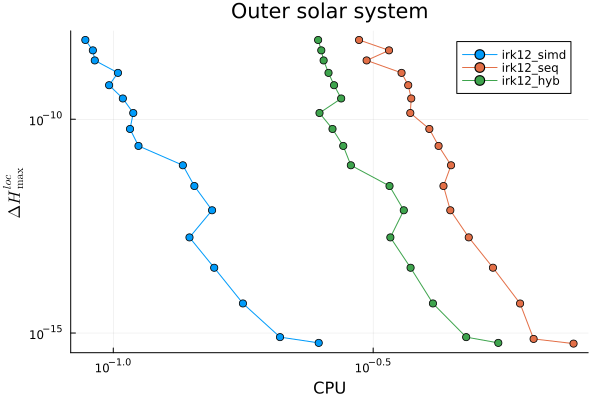

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [10]:
#
sols2plot=[sols_irk12_simd, sols_irk12_seq, sols_irk12_hyb]
labels2plot=["irk12_simd", "irk12_seq", "irk12_hyb"]

pl_=plot(title="Outer solar system", xlabel="CPU", ylabel=L"\Delta H^{loc}_{\mathrm{max}}",
          scale=:log10)

for i in 1:length(sols2plot)
    sols=sols2plot[i]
    plot!(pl_, sols.cpus , sols.MaxΔHlocal, markershape=:circle, label=labels2plot[i])
end
display(pl_)

In [11]:
#[sols_irk162nd_simd2.dts sols_irk162nd_simd2.retcodes s*sols_irk162nd_simd2.iters sols_irk162nd_simd2.cpus sols_irk162nd_simd2.MaxΔHlocal]

In [12]:
#[sols_irk162nd_gen2.dts sols_irk162nd_gen2.retcodes s*sols_irk162nd_gen2.iters  sols_irk162nd_gen2.cpus sols_irk162nd_gen2.MaxΔHlocal]

## SS05(r=8)

In [13]:
flows=[flowH1Nbody!, flowH2Nbody!]
prob=SplittingProblem(flows, u0, tspan, Gm)

HAM=NbodyEnergy
@show(HAM(u0,Gm))

HAM(u0, Gm) = -9.522620605966966e-12


-9.522620605966966e-12

In [14]:
ddt0_split=2 .^(6.3:1/8:7.5)
nruns=1

#
s=21; r=8
alg=Splitting_alg(r=r, rkn=false)
sols_split_r8=run_many_Splitting(s, alg, prob, ddt0_split, HAM, nruns=nruns);


,78.79324245407463,85.92464017793685,93.70148454052001,102.18219345365118,111.43047210190387,121.51579148166644,132.5139102516963,144.50744381518479,157.58648490814926,171.8492803558737

<a href="#top">Back to the top</a>

## Benchmarks diagrams

### Work-precision diagrams (overhead)

In [15]:
sols2plot=[ sols_irk12_simd, sols_irk12_seq, sols_irk12_hyb, sols_split_r8
]

#sols2plot_=[sols_irk12_seq, sols_split_r8]

labels2plot=[ "IRKGL12-SIMD", "IRKGL12-SEQ",  "IRKGL12-HYBR", "SS05(r=8)", "IRKGL12-Fortran", "SS05(r=8)-Fortran"]

#colors2plot = [:red, :blue, :green, :orange, :purple, :cyan, :magenta, :teal, :gold, :gray]
colors2plot = [:red, :blue, :green, :magenta, :pink, :brown]

stages = [8,8,8,21];
nsteps=nstepsirk16=tF./ddt0_irk16
nstepsSS05=tF./(s*ddt0_split)
steps=[nstepsirk16, nstepsirk16, nstepsirk16, nstepsSS05];

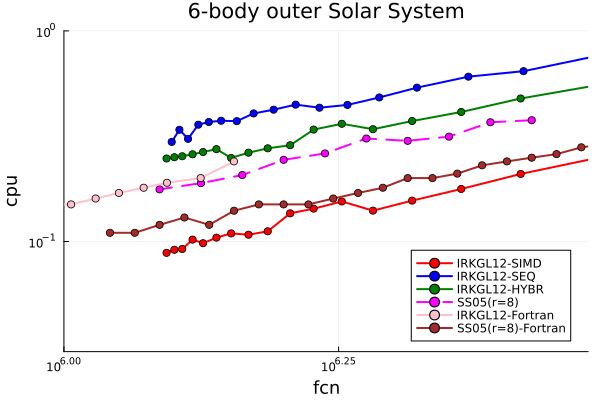

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [16]:
#xrange=(1e-2,1e1)
#xrange=(1e-1,3e0)
yrange=(3e-2,1e0)
xrange=(1e6,3e6)

pl4=plot(scale=:log10,
         ylimits=yrange,
         xlimits=xrange,    
         title="6-body outer Solar System", 
         xlabel="fcn", ylabel="cpu",
         legend=:bottomright,
         guidefont=font(12), labelsize=10)

for i in 1:3
    sols=sols2plot[i]
    fcn=stages[i]*(sols.iters)

    plot!(pl4, fcn, sols.cpus, 
          markershape=:circle, lw=2,
          label=labels2plot[i], color=colors2plot[i])

end

sols=sols2plot[4]
plot!(pl4, sols.nflowsH3 , sols.cpus, 
       markershape=:circle, lw=2, ls=:dash,
       label=labels2plot[4], color=colors2plot[4])


plot!(pl4, fnc_H_irk, cpu_H_irk, 
      markershape=:circle, lw=2,
      label=labels2plot[5], color=colors2plot[5]) 

plot!(pl4, fnc_H_comp, cpu_H_comp, 
      markershape=:circle, lw=2,
      label=labels2plot[6], color=colors2plot[6]) 

display(pl4)

In [17]:
savefig("./figures/Fig20.pdf")

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


"/home/mikel/Nextcloud/Gure taldea (Ehu box)/IRKGL-2025/6-Splitting-metodoak/Splitting Solvers Implementation/Experiments_Article4 (for repository)/4- Comparative with gnicodes-fortran /figures/Fig20.pdf"